In [1]:
# import libraries
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

In [44]:

# define the constants
C = 1e23
r = 6.3781e6
Q = 1365
sigma = 5.6704e-8
# generate a function for the albedo values
temp = [200,247,282,340]
albedo = [0.7,0.7,0.3,0.3]
alpha = lambda T: np.interp(T,temp,albedo)
# temperature axis
T_eq = np.linspace(0,500,1000)

def plot(epsilon):
    eps = epsilon # choose emissivity
    # Define power in and power out functions

    global P_in
    global P_out

    P_in = np.pi * r**2 * Q * (1 - alpha(T_eq))
    P_out = 4 * np.pi * r**2 * sigma * eps * T_eq**4
    # Plot function
    plt.plot(T_eq, P_in, 'b-.', label=r'$P_{in}$') # plot LHS
    plt.plot(T_eq, P_out, 'r', label=r'$P_{out}$') # plot RHS
    plt.title("Power in vs. Power out for the Energy Balance Model")
    plt.xlabel('Temperature, T(t) (Kelvin)') # x axis label
    plt.ylabel('Power P(T) (W)') # y axis label
    plt.grid() # add grid to plot
    plt.xlim([230,310]) #x axis range
    plt.ylim([5e16,1.4e17]) #y axis range
    plt.legend(loc='upper left') # add legend
    plt.gca().get_yaxis().set_major_formatter(ticker.FormatStrFormatter('%.2e'))
    # Find intersection points
    idx = list(filter(lambda x: ((T_eq[x] < 310) and (T_eq[x] > 230)),
    np.argwhere(np.diff(np.sign(P_in - P_out))).flatten()))
    
    if len(idx) == 0:
        print("No intersection points found!")
    else:
        print("Intersection points:")

    for i in idx:
        print(" T:", round(T_eq[i],2), "P: ", '{:0.2e}'.format(P_in[i]))

    plt.plot(T_eq[idx], P_in[idx], 'ko')
    plt.show()

Intersection points:
 T: 233.73 P:  5.23e+16
 T: 261.26 P:  8.08e+16
 T: 289.29 P:  1.22e+17


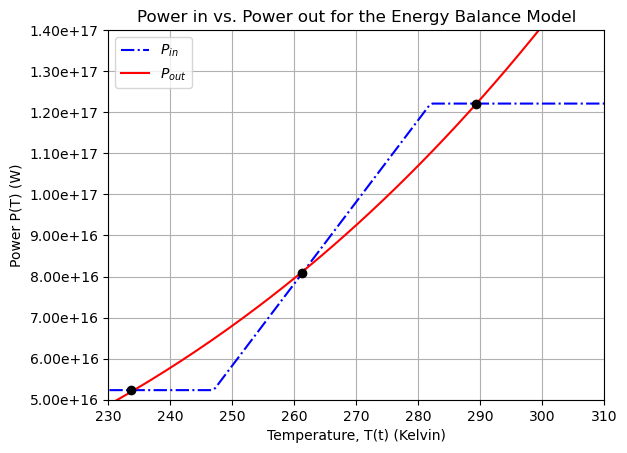

In [45]:
plot(0.6006374223) # plot P_in vs. P_out for given epsilon

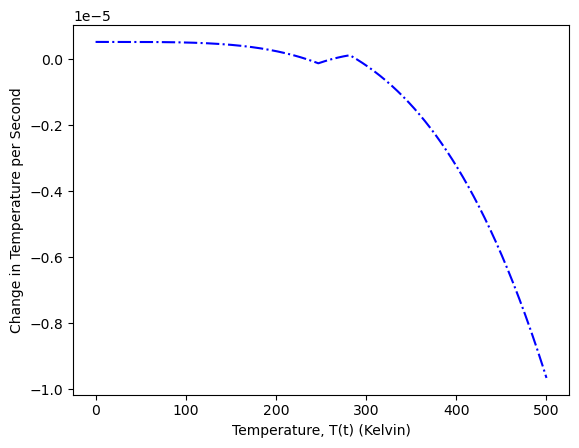

In [46]:
# Noah's own code: 

derivativeT = (P_in - P_out)/C

plt.title("")
plt.xlabel('Temperature, T(t) (Kelvin)') # x axis label
plt.ylabel('Change in Temperature per Second') # y axis label
plt.plot(T_eq, derivativeT, 'b-.') # plot LHS

In [ ]:
# output = dict()

# times = np.linspace(0, 60 * 60 * 24 * 365, 100 )

# output["times"] = times.tolist()
# output["temperatures"] = T_eq[1::20].tolist()

# derivative_temperatures_at_times = []
# for time in times: 
#     derivative_temperatures_at_times.append(derivativeT.tolist()[1::20])
    # for temperature in T_eq: 
    #     derivative_temperatures_at_times[-1].append()


# output["slopes"] = dict()
# for idx, derivative in enumerate(derivativeT[1::20]): 
#     output["slopes"][T_eq[1::20][idx]] = str(derivative)


In [ ]:
# import json
# with open("fieldData.json", "w") as f:
#     json.dump(output, f)

ValueError: too many values to unpack (expected 2)

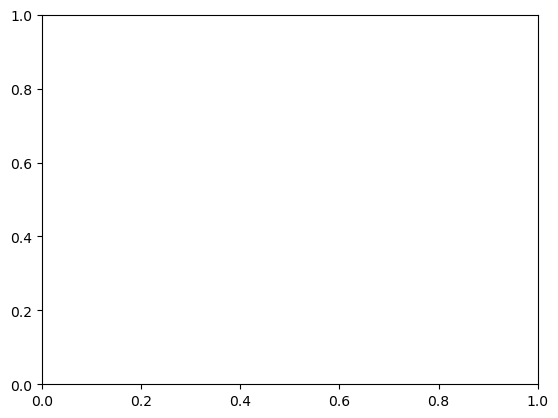

In [ ]:
times = np.linspace(0, 60 * 60 * 24 * 365, 100 )

# T_eq

fig, ax = plt.subplots()

maxDerivative = max(derivativeT)

q = ax.quiver(times, T_eq,  np.cos((np.pi/4) * (derivativeT/maxDerivative)), V)

ax.quiverkey(q, X=0.3, Y=1.1, U=10,
             label='Quiver key, length = 10', labelpos='E')

plt.show()

